## Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import pickle
from numbers import Number
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from esda.moran import Moran
from scipy.stats import spearmanr, norm
from scipy.spatial import distance_matrix
from libpysal.weights import full2W, Queen, KNN
from spreg import ML_LagFE, ML_LagRE, ML_ErrorRE, ML_ErrorFE, PooledOLS, PanelFE, PanelRE


warnings.simplefilter("ignore", category=UserWarning)

In [2]:
base_dir = './'
data_dir = os.path.join(base_dir, 'data')
results_dir = os.path.join(base_dir, 'results')

In [3]:
df = pd.read_csv(os.path.join(data_dir, 'df.csv'))
la = gpd.read_file(os.path.join(data_dir, "..", "raw_data", "irradiance", "LAD_MAY_2024_UK_BFE.shp"))\
        .set_crs("EPSG:27700").to_crs("EPSG:4326")

In [4]:
def compute_weights(y, x, data, shape_data, method='inverse_distance', k=8, verbose=True):
    coords = shape_data[["LAT", "LONG"]].to_numpy()
    if method == 'inverse_distance':
            dist_mat = distance_matrix(coords, coords)
            np.fill_diagonal(dist_mat, np.inf)  # avoid division by zero
            w = 1 / dist_mat # Inverse distance weights
    elif method == 'queen':
            w = Queen.from_dataframe(shape_data, use_index=False)
            if len(w.islands) > 0:
                if verbose:
                    print(f"There are some islands in the data {method}({len(w.islands)}).")
                w_knn = KNN.from_array(coords, k=1)
                for i in w.islands: # use knn neighbors only for islands
                    w.neighbors[i] = w_knn.neighbors[i]
                    w.weights[i] = w_knn.weights[i]
            w.transform = "R"  
            w = w.full()[0]
    elif method == 'k_nearest':
            w = KNN.from_array(coords, k=k)
            if len(w.islands) > 0:
                if verbose:
                    print(f"There are some islands in the data {method}({len(w.islands)}).")
            w.transform = "R"  
            w = w.full()[0]
    w = pd.DataFrame(w, index=shape_data["LAD24CD"], columns=shape_data["LAD24CD"])
    d = data[['code', 'year'] + x + [y]].dropna() # NaNs filter
    if len(d) > 0:
        g_year = d.groupby('code').size().max()
        nonna_codes = []
        for code, group in d.groupby('code'):
            if (group['year'].nunique() < g_year) or (group.dropna().shape[0] < g_year):
                print(f"Code {code} has only {group['year'].nunique()} unique years.")
                pass
            else:
                nonna_codes.append(code)
        n_periods = f"{d['year'].nunique()} ({d['year'].min()}-{d['year'].max()})"
        codes = set(nonna_codes)
        w = w[[i for i in w.columns if i in codes]]
        n_units = w.columns.size
        w = w[[i in codes for i in w.index]]
        d = d[[i in codes for i in d.code]]
        w = full2W(np.asarray(w))
        w.transform = 'R'
        if verbose:
            print(f"Number of units: {n_units}, Number of periods: {n_periods}, Method: {method}")
        Y = d[y].values.reshape(-1, 1)
        X = d[x].values
        return w, X, Y
    else:
        if verbose:
            print("No valid data after dropping NaNs.")
        return None, None, None

def get_stars(p, p001="***", p01="**", p05="*", p10="+", p_=""):
    if not isinstance(p, Number):
        return p
    if p < 0.001:
        return p001
    if p < 0.010:
        return p01
    if p < 0.050:
        return p05
    if p < 0.100:
        return p10
    return p_

def average_correlations(r, n, alpha=0.05, method="two-tailed"):
    """
    r : list/array of correlations
    n : list/array of sample sizes
    """
    r = np.array(r, dtype=float)
    n = np.array(n, dtype=float)

    z = np.arctanh(r)  # 1) Fisher z-transform
    w = n - 3  # 2) Weights (inverse variance)
    z_bar = np.sum(w * z) / np.sum(w)  # 3) Pooled effect (weighted mean z)
    se = 1 / np.sqrt(np.sum(w))  # 4) Standard error of pooled effect
    z = z_bar / se  # 5) Test statistic
    p = 1 - norm.cdf(np.abs(z))  # 6) Two-tailed p-value
    p = p * 2 if method == "two-tailed" else p
    r_bar = np.tanh(z_bar)  # 7) Convert back to correlation
    # 8) CI in z-space, then back-transform
    # z-critical = stats.norm.ppf(1 - alpha) (use alpha = alpha/2 for two-sided)
    a = alpha / 2 if method == "two-tailed" else alpha
    z_crit = norm.ppf(1 - a)
    z_ci_low = z_bar - z_crit * se
    z_ci_high = z_bar + z_crit * se
    r_ci_low = np.tanh(z_ci_low)
    r_ci_high = np.tanh(z_ci_high)
    return {
        "r_mean": r_bar,
        "z_mean": z_bar,
        "se": se,
        "z": z,
        "p-value": p,
        "cil": r_ci_low,
        "cir": r_ci_high,
    }


def average_morans_i(i, i_var, method="two-tailed"):
    """
    I: array of Moran's I values
    var_I: array of variances of Moran's I
    """
    i = np.array(i, dtype=float)
    var_i = np.array(i_var, dtype=float)
    w = 1 / var_i  # weights = inverse variance
    i_bar = np.sum(w * i) / np.sum(w)  # weighted mean
    se = np.sqrt(1 / np.sum(w))  # standard error
    z = i_bar / se  # test statistic
    p = 1 - norm.cdf(np.abs(z))  # p-value (two-tailed)
    p = p * 2 if method == "two-tailed" else p
    return {
        "i_mean": i_bar,
        "z": z,
        "se": se,
        "p-value": p,
    }

## Temporal and spatial dynamics

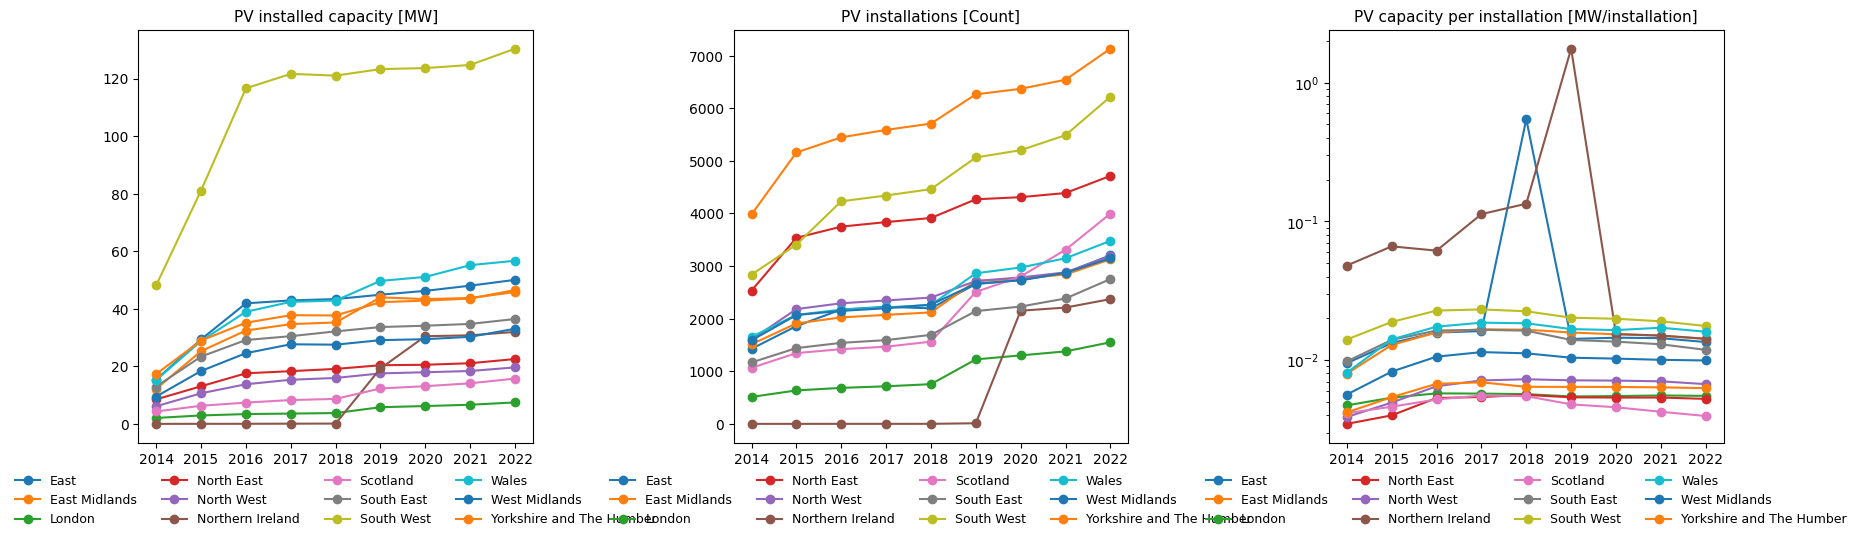

In [32]:
labels = {"log_pv_cap": "PV installed capacity [MW]",
        "log_pv_inst": "PV installations [Count]",
        "pv_cap_per_inst": "PV capacity per installation [MW/installation]",
        }

fig = plt.figure(figsize=(6.0 * 3, 5.5))
ax_left = fig.add_subplot(1, 3, 1)
d = df.copy()
d = d[['year', 'pv_cap', 'region']].groupby(['year', 'region']).mean().reset_index().pivot(index='year', columns='region', values='pv_cap')
d = d.rename(columns=labels)
d.plot(ax=ax_left, marker='o',)
ax_left.set_title(labels['log_pv_cap'], fontsize=11)
ax_left.set_xlabel(None)
ax_left.set_ylabel(None, labelpad=-5)
ax_left.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), 
               fontsize=9, frameon=False, ncols=4)

ax_middle = fig.add_subplot(1, 3, 2)
d = df.copy()
d = d[['year', 'pv_inst', 'region']].groupby(['year', 'region']).mean().reset_index().pivot(index='year', columns='region', values='pv_inst')
d = d.rename(columns=labels)
d.plot(ax=ax_middle, marker='o',)
ax_middle.set_title(labels['log_pv_inst'], fontsize=11)
ax_middle.set_xlabel(None)
ax_middle.set_ylabel(None, labelpad=-5)
ax_middle.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), 
                 fontsize=9, frameon=False, ncols=4)

ax_right = fig.add_subplot(1, 3, 3)
d = df.copy()
d = d[['year', 'pv_cap_per_inst', 'region']].groupby(['year', 'region']).mean().reset_index().pivot(index='year', columns='region', values='pv_cap_per_inst')
d = d.rename(columns=labels)
d.plot(ax=ax_right, marker='o', logy=True)
ax_right.set_title(labels['pv_cap_per_inst'], fontsize=11)
ax_right.set_xlabel(None)
ax_right.set_ylabel(None, labelpad=-5)
ax_right.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), 
                 fontsize=9, frameon=False, ncols=4)  

fig.subplots_adjust(wspace=0.001)
fig.tight_layout(pad=1.01)
fig.savefig(
        os.path.join(results_dir, "fig_dyn.pdf"),
        dpi=1200,
        bbox_inches="tight",
        format="pdf",
    )

## Moran tests

In [6]:
# Global spatial autocorrelation (Moran’s I)
methods = ['inverse_distance', 'k_nearest', 'queen']

f = os.path.join(results_dir, 'moran_results.pickle')
if not os.path.exists(f):
    pv_cap_moran_results = [] 
    for y in df["year"].unique():
        df_y = df[df["year"] == y].copy()
        if len(df_y) > 0 and df_y['log_pv_cap'].notna().sum() > 0:
            d = {'year': y}
            for m in methods:
                w, X, Y = compute_weights('log_pv_cap', ['area'], data=df_y, shape_data=la, method=m, verbose=False)
                if w is not None:
                    mi = Moran(Y, w, transformation="R")
                    d[f'I_{m}'] = mi.I
                    d[f'p_{m}'] = mi.p_sim
                    d[f'VI_{m}'] = mi.VI_rand
            pv_cap_moran_results.append(d)
    pv_cap_moran_results = pd.DataFrame(pv_cap_moran_results)

    pv_inst_moran_results = []
    for y in df["year"].unique():
        df_y = df[df["year"] == y].copy()
        if len(df_y) > 0 and df_y['log_pv_inst'].notna().sum() > 0:
            d = {'year': y}
            for m in methods:
                w, X, Y = compute_weights('log_pv_inst', ['area'], data=df_y, 
                                        shape_data=la, method=m, verbose=False)
                if w is not None:
                    mi = Moran(Y, w, transformation="R")
                    d[f'I_{m}'] = mi.I
                    d[f'p_{m}'] = mi.p_sim
                    d[f'VI_{m}'] = mi.VI_rand
            pv_inst_moran_results.append(d)
    pv_inst_moran_results = pd.DataFrame(pv_inst_moran_results)

    pv_cap_per_inst_moran_results = []
    for y in df["year"].unique():
        df_y = df[df["year"] == y].copy()
        if len(df_y) > 0 and df_y['pv_cap_per_inst'].notna().sum() > 0:
            d = {'year': y}
            for m in methods:
                w, X, Y = compute_weights('pv_cap_per_inst', ['area'], data=df_y, 
                                        shape_data=la, method=m, verbose=False)
                if w is not None:
                    mi = Moran(Y, w, transformation="R")
                    d[f'I_{m}'] = mi.I
                    d[f'p_{m}'] = mi.p_sim
                    d[f'VI_{m}'] = mi.VI_rand
            pv_cap_per_inst_moran_results.append(d)
    pv_cap_per_inst_moran_results = pd.DataFrame(pv_cap_per_inst_moran_results)

    moran_results = {
        "pv_cap": pv_cap_moran_results,
        "pv_inst": pv_inst_moran_results,
        "pv_cap_per_inst": pv_cap_per_inst_moran_results,
    }
    with open(f, 'wb') as f:
            pickle.dump(moran_results, f)
else:
    with open(f, 'rb') as f:
        moran_results = pickle.load(f)
        pv_cap_moran_results, pv_inst_moran_results, pv_cap_per_inst_moran_results =\
            moran_results['pv_cap'], moran_results['pv_inst'], moran_results['pv_cap_per_inst']

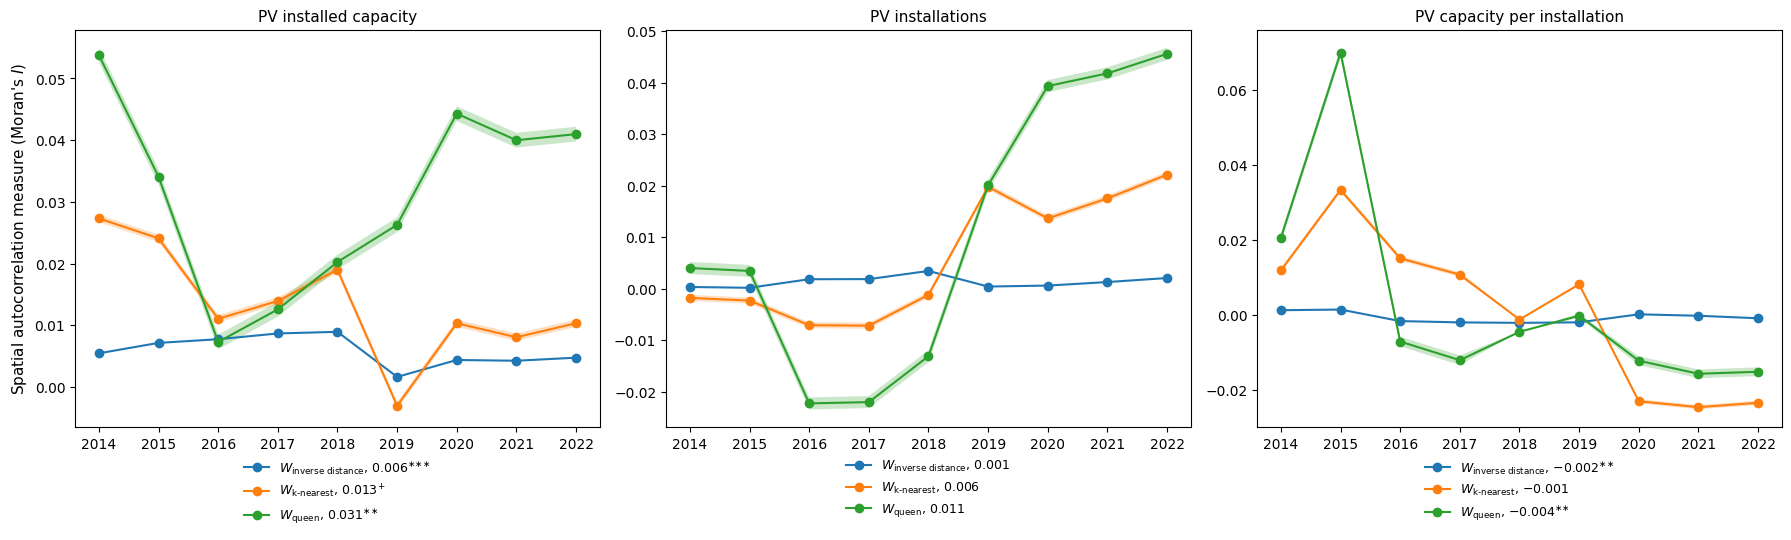

In [7]:
labels = {"log_pv_cap": "PV installed capacity",
        "log_pv_inst": "PV installations",
        "pv_cap_per_inst": "PV capacity per installation",
        
        "I_inverse_distance": r"$W_{\text{inverse distance}}$",
        "I_k_nearest": r"$W_{\text{k-nearest}}$",
        "I_queen": r"$W_{\text{queen}}$"}
methods = ['inverse_distance', 'k_nearest', 'queen']
fig = plt.figure(figsize=(6.0 * 3, 5.5))
ax_left = fig.add_subplot(1, 3, 1)
d = pv_cap_moran_results
for m in methods:
    i = d[['year'] + [i for i in d.columns if i.startswith(f'I_{m}')]].set_index('year')
    v = d[['year'] + [i for i in d.columns if i.startswith(f'VI_{m}')]].set_index('year')
    iv = average_morans_i(i, v)
    labels_ = {k: (f"{v}, ${iv['i_mean']:.3f}" + "^{" + f"{get_stars(iv['p-value'])}" + "}$").replace("*", r"{\ast}") for k, v in labels.items() if m in k}
    i = i.rename(columns=labels_)
    i.plot(ax=ax_left, marker='o',)
    ax_left.fill_between(i.index, i.iloc[:, 0] - v.iloc[:, 0], i.iloc[:, 0] + v.iloc[:, 0], alpha=0.25)
ax_left.set_title(labels['log_pv_cap'], fontsize=11)
ax_left.set_xlabel(None)
ax_left.set_ylabel("Spatial autocorrelation measure (Moran's $I$)", fontsize=11)
ax_left.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), 
               fontsize=9, frameon=False)

ax_middle = fig.add_subplot(1, 3, 2)
d = pv_inst_moran_results
for m in methods:
    i = d[['year'] + [i for i in d.columns if i.startswith(f'I_{m}')]].set_index('year')
    v = d[['year'] + [i for i in d.columns if i.startswith(f'VI_{m}')]].set_index('year')
    iv = average_morans_i(i, v)
    labels_ = {k: (f"{v}, ${iv['i_mean']:.3f}" + "^{" + f"{get_stars(iv['p-value'])}" + "}$").replace("*", r"{\ast}") for k, v in labels.items() if m in k}
    i = i.rename(columns=labels_)
    i.plot(ax=ax_middle, marker='o',)
    ax_middle.fill_between(i.index, i.iloc[:, 0] - v.iloc[:, 0], i.iloc[:, 0] + v.iloc[:, 0], alpha=0.25)
ax_middle.set_title(labels['log_pv_inst'], fontsize=11)
ax_middle.set_xlabel(None)
ax_middle.set_ylabel("", labelpad=-5)
ax_middle.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), 
                 fontsize=9, frameon=False)

ax_right = fig.add_subplot(1, 3, 3)
d = pv_cap_per_inst_moran_results
for m in methods:
    i = d[['year'] + [i for i in d.columns if i.startswith(f'I_{m}')]].set_index('year')
    v = d[['year'] + [i for i in d.columns if i.startswith(f'VI_{m}')]].set_index('year')
    iv = average_morans_i(i, v)
    labels_ = {k: (f"{v}, ${iv['i_mean']:.3f}" + "^{" + f"{get_stars(iv['p-value'])}" + "}$").replace("*", r"{\ast}") for k, v in labels.items() if m in k}
    i = i.rename(columns=labels_)
    i.plot(ax=ax_right, marker='o',)
    ax_right.fill_between(i.index, i.iloc[:, 0] - v.iloc[:, 0], i.iloc[:, 0] + v.iloc[:, 0], alpha=0.25)
ax_right.set_title(labels['pv_cap_per_inst'], fontsize=11)
ax_right.set_xlabel(None)
ax_right.set_ylabel("", labelpad=-5)
ax_right.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), 
                 fontsize=9, frameon=False)  

fig.subplots_adjust(wspace=0.001)
fig.tight_layout(pad=1.01)
fig.savefig(
        os.path.join(results_dir, "fig_moran.pdf"),
        dpi=1200,
        bbox_inches="tight",
        format="pdf",
    )

## Correlations

In [5]:
vars = ["log_gdp_cap",
        "log_income", 
        "log_earnings", 
        "log_population", 
        "log_hholds", 
        "log_employees", 
        "pdensity", 
        "hdensity", 
        "fdensity",
        "adensity",
        "gini_assets",
        "gini_earnings",
        "gini_employees",]
corr_results = [] 
for k in ['log_pv_cap', 'log_pv_inst', 'pv_cap_per_inst']:
    d = {}
    for v in vars:
        df_v = df[[k, v, 'year']].dropna()
        if len(df_v) > 0:
            r, n = [], []
            for y in df_v["year"].unique():
                df_y = df_v[df_v["year"] == y].copy()
                if len(df_y) > 0 and df_y[k].notna().sum() > 0:
                    r_v, p = spearmanr(df_y[k], df_y[v], nan_policy='omit')
                    r.append(r_v)
                    n.append(len(df_y))
            r_a = average_correlations(r, n)
            d[v] = f"{r_a["r_mean"]:.2f}" + "^{" + f"{get_stars(r_a['p-value'])}" + "}"
    corr_results.append({k: d})

corr_results = pd.concat([pd.concat([pd.DataFrame.from_dict(v, orient='index', columns=[k]) 
                      for k, v in i.items()], axis=0) for i in corr_results], axis=1)
# corr_results.to_csv(os.path.join(results_dir, 'avg_corr_results.csv'), index=True)
corr_results

,log_pv_cap,log_pv_inst,pv_cap_per_inst
log_gdp_cap,-0.09^{***},-0.09^{***},-0.02^{}
log_income,-0.07^{***},-0.22^{***},0.13^{***}
log_earnings,-0.25^{***},-0.34^{***},-0.03^{}
log_population,0.14^{***},0.39^{***},-0.13^{***}
log_hholds,0.26^{***},0.51^{***},-0.14^{***}
log_employees,-0.12^{***},-0.04^{*},-0.15^{***}
pdensity,-0.47^{***},-0.27^{***},-0.50^{***}
hdensity,-0.43^{***},-0.22^{***},-0.50^{***}
fdensity,-0.45^{***},-0.27^{***},-0.45^{***}
adensity,-0.45^{***},-0.35^{***},-0.39^{***}


In [6]:
pv_cap_corr_results = [] 
for y in df["year"].unique():
    df_y = df[df["year"] == y].copy()
    if len(df_y) > 0 and df_y['log_pv_cap'].notna().sum() > 0:
        d = {'year': y}
        for v in vars:
            r_v, p = spearmanr(df_y['log_pv_cap'], df_y[v], nan_policy='omit')
            d[f'r_{v}'] = r_v
            d[f'p_{v}'] = p
        pv_cap_corr_results.append(d)
pv_cap_corr_results = pd.DataFrame(pv_cap_corr_results)

pv_inst_corr_results = [] 
for y in df["year"].unique():
    df_y = df[df["year"] == y].copy()
    if len(df_y) > 0 and df_y['log_pv_inst'].notna().sum() > 0:
        d = {'year': y}
        for v in vars:
            r_v, p = spearmanr(df_y['log_pv_inst'], df_y[v], nan_policy='omit')
            d[f'r_{v}'] = r_v
            d[f'p_{v}'] = p
        pv_inst_corr_results.append(d)
pv_inst_corr_results = pd.DataFrame(pv_inst_corr_results)

pv_cap_per_inst_corr_results = [] 
for y in df["year"].unique():
    df_y = df[df["year"] == y].copy()
    if len(df_y) > 0 and df_y['log_pv_cap_per_inst'].notna().sum() > 0:
        d = {'year': y}
        for v in vars:
            r_v, p = spearmanr(df_y['log_pv_cap_per_inst'], df_y[v], nan_policy='omit')
            d[f'r_{v}'] = r_v
            d[f'p_{v}'] = p
        pv_cap_per_inst_corr_results.append(d)
pv_cap_per_inst_corr_results = pd.DataFrame(pv_cap_per_inst_corr_results)

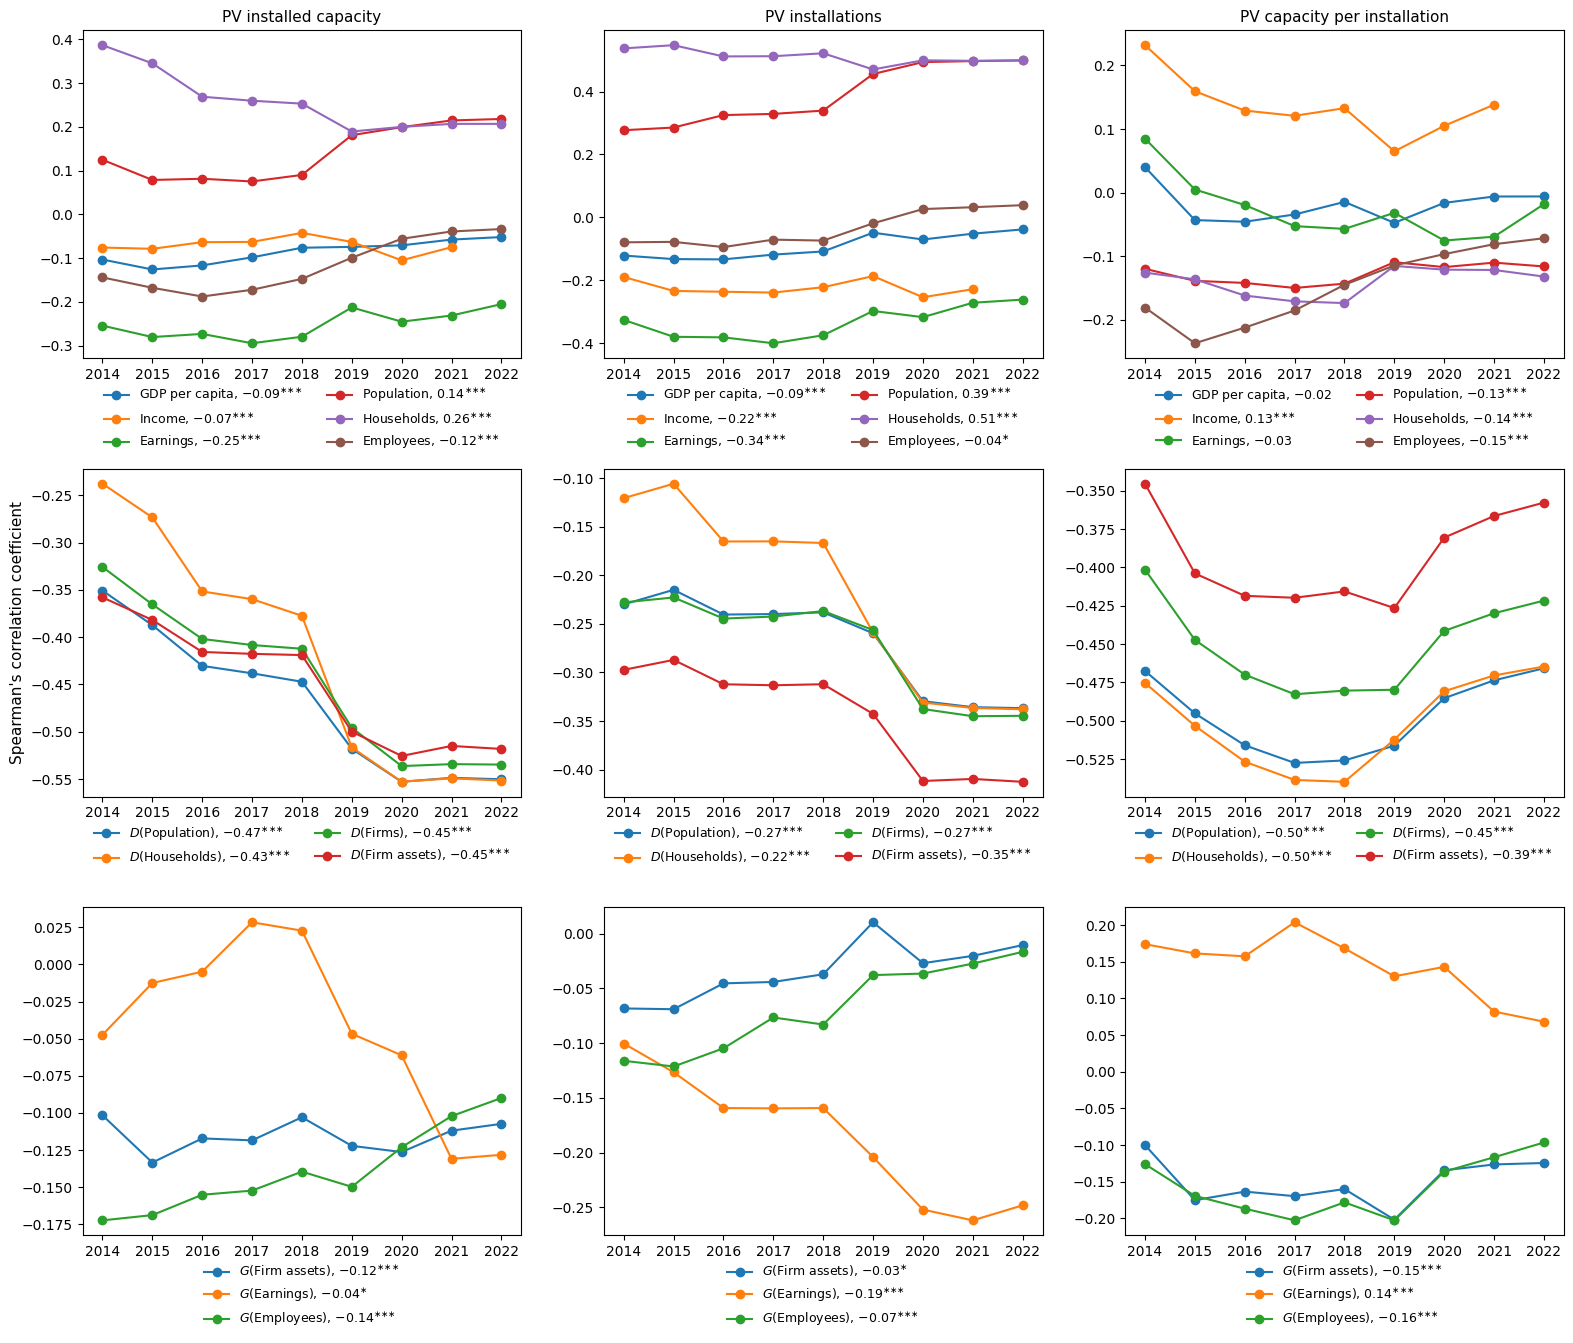

In [28]:
labels = {"r_log_gdp_cap": "GDP per capita",
        "r_log_income": "Income", 
        "r_log_earnings": "Earnings", 
        
        "r_log_population": "Population", 
        "r_log_hholds": "Households",
        "r_log_employees": "Employees", 

        "r_pdensity": "$D$(Population)", 
        "r_hdensity": "$D$(Households)", 
        "r_fdensity": "$D$(Firms)",
        "r_adensity": "$D$(Firm assets)",

        "r_gini_earnings": "$G$(Earnings)",
        "r_gini_assets": "$G$(Firm assets)",
        "r_gini_employees": "$G$(Employees)",

        "log_pv_cap": "PV installed capacity",
        "log_pv_inst": "PV installations",
        "pv_cap_per_inst": "PV capacity per installation"}

fig = plt.figure(figsize=(5.3 * 3, 4.5 * 3))

vars1 = ["log_gdp_cap",
        "log_income", 
        "log_earnings", 
        "log_population", 
        "log_hholds", 
        "log_employees", 
        #"pdensity", 
        #"hdensity", 
        #"fdensity",
        #"adensity",
        #"gini_assets",
        #"gini_earnings",
        #"gini_employees",
        ]

ax_left = fig.add_subplot(3, 3, 1)
d = pv_cap_corr_results.copy()
d = d[['year'] + [c for v in vars1 for c in d.columns if v in str(c)]]
d = d[['year'] + [i for i in d.columns if i.startswith('r_')]]
labels_ = {k: f"{v}, ${r['log_pv_cap']}$".replace("*", r"{\ast}") for k, v in labels.items() for i, r in corr_results.iterrows() if i == k[2:]}
d = d.rename(columns=labels_).set_index('year')
d.plot(ax=ax_left, marker='o',)
ax_left.set_title(labels['log_pv_cap'], fontsize=11)
ax_left.set_xlabel(None)
#ax_left.set_ylabel("Spearman's correlation coefficient", fontsize=11)
ax_left.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), 
               ncol=2, fontsize=9, frameon=False)

ax_middle = fig.add_subplot(3, 3, 2)
d = pv_inst_corr_results.copy()
d = d[['year'] + [c for v in vars1 for c in d.columns if v in str(c)]]
d = d[['year'] + [i for i in d.columns if i.startswith('r_')]]
labels_ = {k: f"{v}, ${r['log_pv_inst']}$".replace("*", r"{\ast}") for k, v in labels.items() for i, r in corr_results.iterrows() if i == k[2:]}
d = d.rename(columns=labels_).set_index('year')
d.plot(ax=ax_middle, marker='o',)
ax_middle.set_title(labels['log_pv_inst'], fontsize=11)
ax_middle.set_xlabel(None)
ax_middle.set_ylabel("", labelpad=-5)
ax_middle.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), 
                 ncol=2, fontsize=9, frameon=False)

ax_right = fig.add_subplot(3, 3, 3)
d = pv_cap_per_inst_corr_results.copy()
d = d[['year'] + [c for v in vars1 for c in d.columns if v in str(c)]]
d = d[['year'] + [i for i in d.columns if i.startswith('r_')]]
labels_ = {k: f"{v}, ${r['pv_cap_per_inst']}$".replace("*", r"{\ast}") for k, v in labels.items() for i, r in corr_results.iterrows() if i == k[2:]}
d = d.rename(columns=labels_).set_index('year')
d.plot(ax=ax_right, marker='o',)
ax_right.set_title(labels['pv_cap_per_inst'], fontsize=11)
ax_right.set_xlabel(None)
ax_right.set_ylabel("", labelpad=-5)
ax_right.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), 
                 ncol=2, fontsize=9, frameon=False)

vars2 = [#"log_gdp_cap",
        #"log_income", 
        #"log_earnings", 
        #"log_population", 
        #"log_hholds", 
        #"log_employees", 
        "pdensity", 
        "hdensity", 
        "fdensity",
        "adensity",
        #"gini_assets",
        #"gini_earnings",
        #"gini_employees",
        ]

ax_left = fig.add_subplot(3, 3, 4)
d = pv_cap_corr_results.copy()
d = d[['year'] + [c for v in vars2 for c in d.columns if v in str(c)]]
d = d[['year'] + [i for i in d.columns if i.startswith('r_')]]
labels_ = {k: f"{v}, ${r['log_pv_cap']}$".replace("*", r"{\ast}") for k, v in labels.items() for i, r in corr_results.iterrows() if i == k[2:]}
d = d.rename(columns=labels_).set_index('year')
d.plot(ax=ax_left, marker='o',)
#ax_left.set_title(labels['log_pv_cap'], fontsize=11)
ax_left.set_xlabel(None)
ax_left.set_ylabel("Spearman's correlation coefficient", fontsize=11)
ax_left.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), 
               ncol=2, fontsize=9, frameon=False)

ax_middle = fig.add_subplot(3, 3, 5)
d = pv_inst_corr_results.copy()
d = d[['year'] + [c for v in vars2 for c in d.columns if v in str(c)]]
d = d[['year'] + [i for i in d.columns if i.startswith('r_')]]
labels_ = {k: f"{v}, ${r['log_pv_inst']}$".replace("*", r"{\ast}") for k, v in labels.items() for i, r in corr_results.iterrows() if i == k[2:]}
d = d.rename(columns=labels_).set_index('year')
d.plot(ax=ax_middle, marker='o',)
#ax_middle.set_title(labels['log_pv_inst'], fontsize=11)
ax_middle.set_xlabel(None)
ax_middle.set_ylabel("", labelpad=-5)
ax_middle.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), 
                 ncol=2, fontsize=9, frameon=False)

ax_right = fig.add_subplot(3, 3, 6)
d = pv_cap_per_inst_corr_results.copy()
d = d[['year'] + [c for v in vars2 for c in d.columns if v in str(c)]]
d = d[['year'] + [i for i in d.columns if i.startswith('r_')]]
labels_ = {k: f"{v}, ${r['pv_cap_per_inst']}$".replace("*", r"{\ast}") for k, v in labels.items() for i, r in corr_results.iterrows() if i == k[2:]}
d = d.rename(columns=labels_).set_index('year')
d.plot(ax=ax_right, marker='o',)
#ax_right.set_title(labels['pv_cap_per_inst'], fontsize=11)
ax_right.set_xlabel(None)
ax_right.set_ylabel("", labelpad=-5)
ax_right.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), 
                 ncol=2, fontsize=9, frameon=False)


vars3 = [#"log_gdp_cap",
        #"log_income", 
        #"log_earnings", 
        #"log_population", 
        #"log_hholds", 
        #"log_employees", 
        #"pdensity", 
        #"hdensity", 
        #"fdensity",
        #"adensity",
        "gini_assets",
        "gini_earnings",
        "gini_employees",
        ]

ax_left = fig.add_subplot(3, 3, 7)
d = pv_cap_corr_results.copy()
d = d[['year'] + [c for v in vars3 for c in d.columns if v in str(c)]]
d = d[['year'] + [i for i in d.columns if i.startswith('r_')]]
labels_ = {k: f"{v}, ${r['log_pv_cap']}$".replace("*", r"{\ast}") for k, v in labels.items() for i, r in corr_results.iterrows() if i == k[2:]}
d = d.rename(columns=labels_).set_index('year')
d.plot(ax=ax_left, marker='o',)
#ax_left.set_title(labels['log_pv_cap'], fontsize=11)
ax_left.set_xlabel(None)
#ax_left.set_ylabel("Spearman's correlation coefficient", fontsize=11)
ax_left.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), 
               ncol=1, fontsize=9, frameon=False)

ax_middle = fig.add_subplot(3, 3, 8)
d = pv_inst_corr_results.copy()
d = d[['year'] + [c for v in vars3 for c in d.columns if v in str(c)]]
d = d[['year'] + [i for i in d.columns if i.startswith('r_')]]
labels_ = {k: f"{v}, ${r['log_pv_inst']}$".replace("*", r"{\ast}") for k, v in labels.items() for i, r in corr_results.iterrows() if i == k[2:]}
d = d.rename(columns=labels_).set_index('year')
d.plot(ax=ax_middle, marker='o',)
#ax_middle.set_title(labels['log_pv_inst'], fontsize=11)
ax_middle.set_xlabel(None)
ax_middle.set_ylabel("", labelpad=-5)
ax_middle.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), 
                 ncol=1, fontsize=9, frameon=False)

ax_right = fig.add_subplot(3, 3, 9)
d = pv_cap_per_inst_corr_results.copy()
d = d[['year'] + [c for v in vars3 for c in d.columns if v in str(c)]]
d = d[['year'] + [i for i in d.columns if i.startswith('r_')]]
labels_ = {k: f"{v}, ${r['pv_cap_per_inst']}$".replace("*", r"{\ast}") for k, v in labels.items() for i, r in corr_results.iterrows() if i == k[2:]}
d = d.rename(columns=labels_).set_index('year')
d.plot(ax=ax_right, marker='o',)
#ax_right.set_title(labels['pv_cap_per_inst'], fontsize=11)
ax_right.set_xlabel(None)
ax_right.set_ylabel("", labelpad=-5)
ax_right.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), 
                 ncol=1, fontsize=9, frameon=False)


fig.subplots_adjust(wspace=0.001)
fig.tight_layout(pad=1.01)
fig.savefig(
        os.path.join(results_dir, "fig_corr1.pdf"),
        dpi=1200,
        bbox_inches="tight",
        format="pdf",
    )

In [25]:
vars = [ 
        "log_pv_cap",
        "log_pv_inst",
        "pv_cap_per_inst",

        "log_gdp_cap",
        "log_income", 
        "log_earnings", 
        "log_assets",

        "log_population", 
        "log_hholds", 
        "log_employees", 

        "pdensity", 
        "hdensity", 
        "fdensity",
        "adensity",

        "gini_earnings",
        "gini_assets",
        "gini_employees",
        ]
full_corr_results_r = {} 
full_corr_results_p = {} 
for v1 in vars:
    full_corr_results_r.setdefault(v1, {})
    full_corr_results_p.setdefault(v1, {})
    for v2 in vars:
        if v1 == v2:
            continue
        full_corr_results_r[v1].setdefault(v2, 0)
        full_corr_results_p[v1].setdefault(v2, 0)
        df_v = df[[v1, v2, 'year']].dropna()
        if len(df_v) > 0:
            r, n = [], []
            for y in df_v["year"].unique():
                df_y = df_v[df_v["year"] == y].copy()
                if len(df_y) > 0 and df_y[v1].notna().sum() > 0:
                    r_v, p = spearmanr(df_y[v1], df_y[v2], nan_policy='omit')
                    r.append(r_v)
                    n.append(len(df_y))
            r_a = average_correlations(r, n)
            full_corr_results_r[v1][v2] = r_a['r_mean'] # f"{r_a["r_mean"]:.2f}" + "^{" + f"{get_stars(r_a['p-value'])}" + "}"
            full_corr_results_p[v1][v2] = r_a['p-value'] 

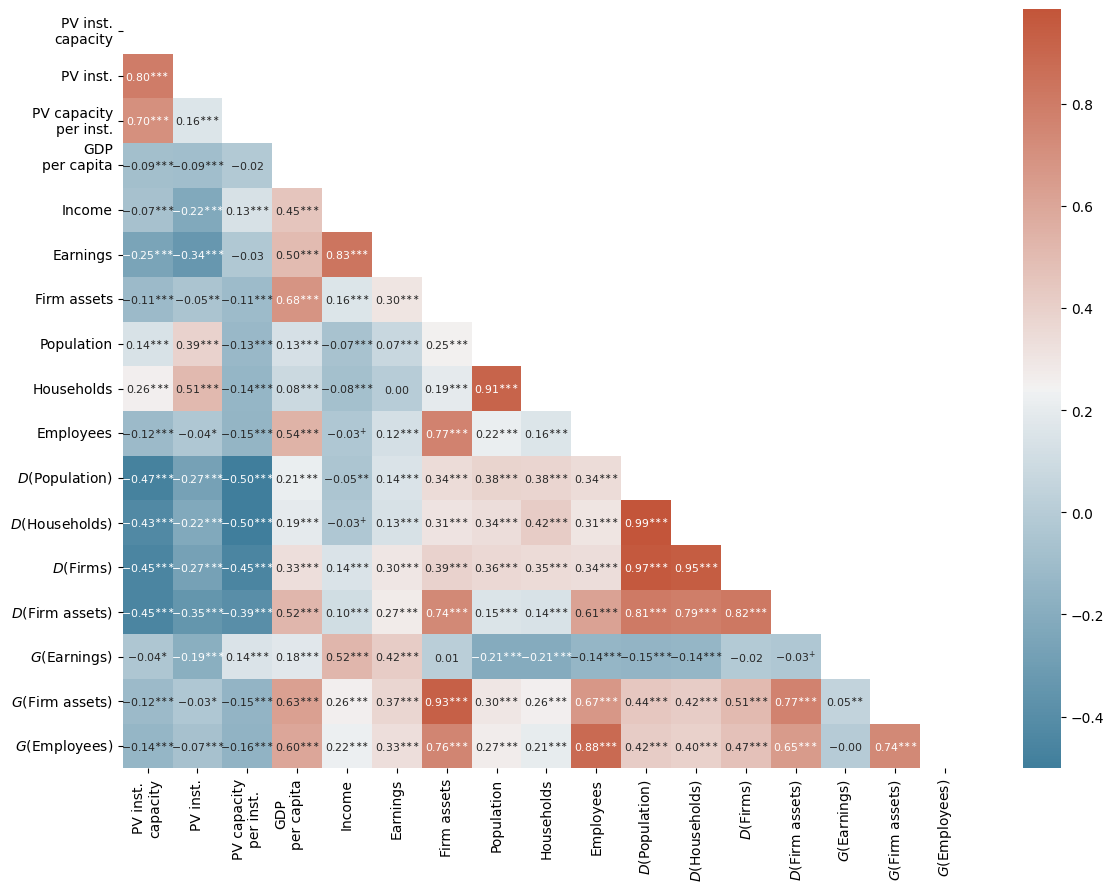

In [26]:
labels = {
    
        "log_pv_cap": "PV inst.\ncapacity",
        "log_pv_inst": "PV inst.",
        "pv_cap_per_inst": "PV capacity\nper inst.",
    
        "log_gdp_cap": "GDP\nper capita\n",
        "log_income": "Income", 
        "log_earnings": "Earnings", 
        "log_assets": "Firm assets", 

        "log_population": "Population", 
        "log_hholds": "Households",
        "log_employees": "Employees", 
        
        "pdensity": "$D$(Population)", 
        "hdensity": "$D$(Households)", 
        "fdensity": "$D$(Firms)",
        "adensity": "$D$(Firm assets)",

        "gini_earnings": "$G$(Earnings)",
        "gini_assets": "$G$(Firm assets)",
        "gini_employees": "$G$(Employees)",
}

fig = plt.figure(figsize=(12, 9))
ax_left = fig.add_subplot()
c = pd.DataFrame(full_corr_results_r).copy()
c = c.reindex(index=labels.keys(), columns=labels.keys())
p = pd.DataFrame(full_corr_results_p).copy()
p = p.reindex(index=labels.keys(), columns=labels.keys())
a = c.copy().astype(str)
for i in a.keys():
    for j in a[i].keys():
        a.loc[i, j] = f"${c[i][j]:.2f}^{{{get_stars(p[i][j])}}}$".replace('*', r'{\ast}')
c = c.rename(columns=labels)
c.index = c.index.map(labels)
cmap = sns.diverging_palette(230, 20, n=256, as_cmap=True) #cmap="YlGnBu"
mask = np.triu(np.ones_like(c, dtype=bool))
ax_left = sns.heatmap(c, cmap=cmap, mask=mask, annot_kws={'va':'center', 'fontsize': 7.8}, fmt='', 
                 robust=False, ax=ax_left, cbar=True, annot=a)
fig.tight_layout(pad=1.01)
fig.savefig(
        os.path.join(results_dir, "fig_corr2.pdf"),
        dpi=1200,
        bbox_inches="tight",
        format="pdf",
    )

## Models

In [55]:
y = 'log_pv_cap'
x = ['log_income', 'log_house_price', 'hholds_density', 'fdensity']
w_method = 'inverse_distance'
w, X, Y = compute_weights(y, x, df, method=w_method)
model = PanelRE(Y, X, w=w, name_y=y, name_x=x, name_w=w_method)
print(model.summary)

Number of units: 311, Number of periods: 8 (2014-2021)
PanelRE
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: RANDOM EFFECTS (ONE-WAY) PANEL
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :inverse_distance
Dependent Variable  :  log_pv_cap                Number of Observations:        2488
Mean dependent var  :      1.2067                Number of Variables   :           5
S.D. dependent var  :      0.5055                Degrees of Freedom    :        2483
Pseudo R-squared    :      0.2168
Sum squared residual:     497.678                F-statistic           :    171.8164
Sigma-square        :       0.200                Prob(F-statistic)     :  4.841e-130
S.E. of regression  :       0.447                Log likelihood        :   -1528.374
Sigma-square ML     :       0.200                Akaike info criterion :    3066.748
S.E of regression ML:      0.4472                Schwarz crite

In [11]:
y = 'log_pv_cap'
x = ['log_income', 'log_house_price', 'hholds_density', 'fdensity']
w_method = 'inverse_distance'
w, X, Y = compute_weights(y, x, df, method=w_method)
model = ML_LagFE(Y, X, w=w, name_y=y, name_x=x, name_w=w_method)
print(model.summary)

Number of units: 311, Number of periods: 8 (2014-2021)
ML_LagFE
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL LAG PANEL - FIXED EFFECTS
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :inverse_distance
Dependent Variable  :  log_pv_cap                Number of Observations:        2488
Mean dependent var  :     -0.0000                Number of Variables   :           5
S.D. dependent var  :      0.4780                Degrees of Freedom    :        2483
Pseudo R-squared    :      0.2723
Log likelihood      :  -1311.4918
Sigma-square ML     :      0.1664                Akaike info criterion :    2632.984
S.E of regression   :      0.4079                Schwarz criterion     :    2662.080
Fixed-effects mean  :      1.1858

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic   

In [276]:
y = 'log_pv_cap'
x = ['log_income', 'log_house_price', 'hholds_density']
w_method = 'queen'
w, X, Y = compute_weights(y, x, df, method=w_method)
model = ML_LagFE(Y, X, w=w, name_y=y, name_x=x, name_w=w_method)
print(model.summary)

c:\UK\.venv\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 8 disconnected components.
 There are 6 islands with ids: 43, 49, 312, 319, 321, 339.
  W.__init__(self, neighbors, ids=ids, **kw)
c:\UK\.venv\Lib\site-packages\libpysal\weights\util.py:761: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
 There are 3 islands with ids: 41, 47, 289.
  return W(neighbors, weights, id_order=ids, **kwargs)


('WARNING: ', 43, ' is an island (no neighbors)')
('WARNING: ', 49, ' is an island (no neighbors)')
('WARNING: ', 312, ' is an island (no neighbors)')
('WARNING: ', 319, ' is an island (no neighbors)')
('WARNING: ', 321, ' is an island (no neighbors)')
('WARNING: ', 339, ' is an island (no neighbors)')
('WARNING: ', 41, ' is an island (no neighbors)')
('WARNING: ', 47, ' is an island (no neighbors)')
('WARNING: ', 289, ' is an island (no neighbors)')
Number of units: 311, Number of periods: 8 (2014-2021)
ML_LagFE
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL LAG PANEL - FIXED EFFECTS
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :       queen
Dependent Variable  :  log_pv_cap                Number of Observations:        2488
Mean dependent var  :     -0.0000                Number of Variables   :           4
S.D. dependent var  :      0.4780                Degrees of Fre

In [279]:
y = 'log_pv_cap'
x = ['log_income', 'log_house_price', 'hholds_density']
w_method = 'k_nearest'
k = 8
w, X, Y = compute_weights(y, x, df, method=w_method, k=k)
model = ML_LagFE(Y, X, w=w, name_y=y, name_x=x, name_w=f"{w_method}(k={k})")
print(model.summary)

Number of units: 311, Number of periods: 8 (2014-2021)
ML_LagFE
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL LAG PANEL - FIXED EFFECTS
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :k_nearest(k=8)
Dependent Variable  :  log_pv_cap                Number of Observations:        2488
Mean dependent var  :     -0.0000                Number of Variables   :           4
S.D. dependent var  :      0.4780                Degrees of Freedom    :        2484
Pseudo R-squared    :      0.3372
Log likelihood      :  -1226.7401
Sigma-square ML     :      0.1519                Akaike info criterion :    2461.480
S.E of regression   :      0.3898                Schwarz criterion     :    2484.757
Fixed-effects mean  :      0.6459

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     